In [3]:
"""
import pandas as pd

# Run this cell to load the dataset
data_sales = {
    'Region': ['North', 'North', 'South', 'East', 'South', 'East', 'North', 'South'],
    'Category': ['Electronics', 'Clothing', 'Electronics', 'Clothing', 'Clothing', 'Electronics', 'Electronics', 'Clothing'],
    'Jan_Revenue': [5000, 2000, 6000, 3000, 2500, 4500, 5200, 2100],
    'Feb_Revenue': [5500, 2100, 5900, 3100, 2600, 4700, 5100, 2200]
}
df_sales = pd.DataFrame(data_sales)

1. Display the structural information and the statistical summary of the dataframe.

2. Find the total revenue across both January and February for each row, adding it as a new column named Total_Revenue.

3. Find the lowest single revenue amount recorded in Jan_Revenue across all entries.

4. Group the data by both Region and Category, and calculate the total Total_Revenue for each specific combination.
"""

import pandas as pd

data_sales = {
    'Region': ['North', 'North', 'South', 'East', 'South', 'East', 'North', 'South'],
    'Category': ['Electronics', 'Clothing', 'Electronics', 'Clothing', 'Clothing', 'Electronics', 'Electronics', 'Clothing'],
    'Jan_Revenue': [5000, 2000, 6000, 3000, 2500, 4500, 5200, 2100],
    'Feb_Revenue': [5500, 2100, 5900, 3100, 2600, 4700, 5100, 2200]
}
dfSales = pd.DataFrame(data_sales)
#1
dfSales.info()
display(dfSales.describe())
display(dfSales.head())

#2
dfSales['Total_Revenue']=dfSales.sum(axis=1,numeric_only =True)
display(dfSales)

#3
minPerJan = dfSales['Jan_Revenue'].min()
print(f"The minimum entry in January is: {minPerJan}")

#4
groupData = dfSales.groupby(['Region','Category'])['Total_Revenue'].sum().reset_index()
display(groupData)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Region       8 non-null      object
 1   Category     8 non-null      object
 2   Jan_Revenue  8 non-null      int64 
 3   Feb_Revenue  8 non-null      int64 
dtypes: int64(2), object(2)
memory usage: 384.0+ bytes


,Jan_Revenue,Feb_Revenue
count,8.000000,8.000000
mean,3787.500000,3900.000000
std,1567.014906,1562.964217
min,2000.000000,2100.000000
25%,2400.000000,2500.000000
50%,3750.000000,3900.000000
75%,5050.000000,5200.000000
max,6000.000000,5900.000000


,Region,Category,Jan_Revenue,Feb_Revenue
0,North,Electronics,5000,5500
1,North,Clothing,2000,2100
2,South,Electronics,6000,5900
3,East,Clothing,3000,3100
4,South,Clothing,2500,2600


,Region,Category,Jan_Revenue,Feb_Revenue,Total_Revenue
0,North,Electronics,5000,5500,10500
1,North,Clothing,2000,2100,4100
2,South,Electronics,6000,5900,11900
3,East,Clothing,3000,3100,6100
4,South,Clothing,2500,2600,5100
5,East,Electronics,4500,4700,9200
6,North,Electronics,5200,5100,10300
7,South,Clothing,2100,2200,4300


The minimum entry in January is: 2000


,Region,Category,Total_Revenue
0,East,Clothing,6100
1,East,Electronics,9200
2,North,Clothing,4100
3,North,Electronics,20800
4,South,Clothing,9400
5,South,Electronics,11900


,Student_Name,Physics,Chemistry,Phy_Normalised
0,Arjun,65,70,0.425532
1,Bhavya,88,85,0.914894
2,Chirag,45,50,0.000000
3,Divya,92,90,1.000000
4,Eshan,78,80,0.702128


,Student_Name,Physics,Chemistry,Phy_Normalised,Avg_Score
0,Arjun,65,70,0.425532,67.5
1,Bhavya,88,85,0.914894,86.5
2,Chirag,45,50,0.000000,47.5
3,Divya,92,90,1.000000,91.0
4,Eshan,78,80,0.702128,79.0


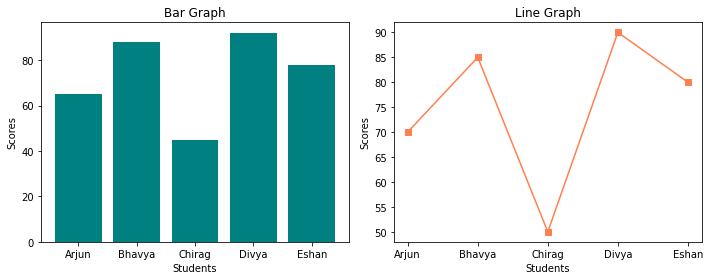

In [10]:
"""
import numpy as np
import matplotlib.pyplot as plt

# Run this cell to load the dataset
data_scores = {
    'Student_Name': ['Arjun', 'Bhavya', 'Chirag', 'Divya', 'Eshan'],
    'Physics': [65, 88, 45, 92, 78],
    'Chemistry': [70, 85, 50, 90, 80]
}
df_scores = pd.DataFrame(data_scores)

Write a custom Python function to normalize a column's data to a scale of 0 to 1 using the formula: (value - min) / (max - min). Apply this function to the Physics column and save the result as Physics_Normalized.

Calculate the average score of each student across both subjects (row-wise mean) and 
store it in a column called Average_Score.

Create a 1x2 Matplotlib subplot (one row, two side-by-side charts) with a figure size of (10, 4):

Plot 1 (Left): A bar chart showing the raw Physics scores of each student. Set the bar color to 'teal' and title it "Physics Scores".

Plot 2 (Right): A line plot showing the Chemistry scores of each student. Add markers (e.g., marker='o'), set the line color to 'coral', and title it "Chemistry Scores".

Ensure both plots have correct X and Y axis labels, and use plt.tight_layout() to prevent overlap.
"""

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Run this cell to load the dataset
data_scores = {
    'Student_Name': ['Arjun', 'Bhavya', 'Chirag', 'Divya', 'Eshan'],
    'Physics': [65, 88, 45, 92, 78],
    'Chemistry': [70, 85, 50, 90, 80]
}
dfScores = pd.DataFrame(data_scores)

#1
def normFunc(col):
    return (col-col.min())/(col.max()-col.min())
dfScores['Phy_Normalised'] = normFunc(dfScores['Physics'])
display(dfScores)
#2
dfScores['Avg_Score']=dfScores[['Physics','Chemistry']].mean(axis=1)
display(dfScores)
#3
fig,axes = plt.subplots(nrows=1,ncols=2,figsize=(10,4))
axes[0].bar(dfScores['Student_Name'],dfScores['Physics'],color='teal')
axes[0].set_title('Bar Graph')
axes[0].set_xlabel('Students')
axes[0].set_ylabel('Scores')

axes[1].plot(dfScores['Student_Name'],dfScores['Chemistry'],marker='s',color='coral')
axes[1].set_title('Line Graph')
axes[1].set_xlabel('Students')
axes[1].set_ylabel('Scores')

plt.tight_layout()
plt.show()

In [ ]:
"""
# Run this cell to load the dataset
data_weather = {
    'Month': ['Jan', 'Jan', 'Feb', 'Feb', 'Mar', 'Mar', 'Apr', 'Apr'],
    'City': ['Pune', 'Nagpur', 'Pune', 'Nagpur', 'Pune', 'Nagpur', 'Pune', 'Nagpur'],
    'Temperature_C': [20, 25, 23, 29, 28, 35, 33, 40],
    'Rainfall_mm': [5, 2, 0, 0, 12, 5, 25, 10]
}
df_weather = pd.DataFrame(data_weather)

Group the dataframe by Month and City. Find the maximum Temperature_C and the sum of Rainfall_mm for each grouping.

Filter the dataframe to isolate only the data for Pune.

Filter the dataframe to isolate only the data for Nagpur.

Create a single Matplotlib figure showing the Temperature trend over the months. 
Plot both Pune's and Nagpur's temperatures on the same graph using line plots. 
Include a legend so the viewer knows which line belongs to which city.

"""

In [ ]:
"""
import pandas as pd
import matplotlib.pyplot as plt

# Run this to load the dataset
data_ecomm = {
    'Order_ID': ['101', '102', '103', '104', '105', '106', '107', '108'],
    'Date': ['2026-01-15', '2026-01-20', '2026-02-10', '2026-02-25', '2026-01-05', '2026-02-15', '2026-01-28', '2026-02-22'],
    'Category': ['Tech', 'Furniture', 'Tech', 'Tech', 'Furniture', 'Furniture', 'Tech', 'Furniture'],
    'Profit': [200, 150, 300, -50, 100, 250, 400, -20]
}
df_ecomm = pd.DataFrame(data_ecomm)
Extract the "Month" from the Date column (e.g., '01' or '02') and store it in a new column called Month. (Hint: String slicing or pd.to_datetime will work).

Create a Pivot Table that shows the total Profit for each Category (rows) across each Month (columns).

Using the resulting pivot table, create a Stacked Bar Chart using Matplotlib. 
Ensure the X-axis represents the Categories, and the stacked bars represent the profit from January and February.
Add a legend, title, and labels.
"""

In [ ]:
"""
import numpy as np

# Run this to load the dataset
np.random.seed(42) # Keeps the random numbers the same every time
sensor_data = np.random.randint(10, 100, size=(5, 4))

Print the raw sensor_data matrix.

Find the mathematical mean of each column.

Broadcasting/Masking Challenge: Create a new matrix where any value in sensor_data that is strictly less than its respective column's mean is replaced by 0. Leave the other values as they are.

Compute the dot product  of this new matrix with its own transpose.

"""

In [ ]:
"""
# Run this to load the dataset
data_hr = {
    'Department': ['Sales', 'Sales', 'Sales', 'IT', 'IT', 'IT', 'HR', 'HR'],
    'Employee': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H'],
    'Salary_LPA': [6, 8, 12, 10, 15, 14, 5, 7],
    'Performance_Score': [3.5, 4.2, 4.8, 4.0, 4.9, 4.1, 3.2, 4.5]
}
df_hr = pd.DataFrame(data_hr)

Group the data by Department. Calculate the average (mean) Salary_LPA and the maximum Performance_Score for each department. Save this aggregated DataFrame.

Create a Matplotlib figure with a single plot, but two Y-axes:

Left Y-axis: Create a bar chart showing the average Salary_LPA for each department. Color it light blue.

Right Y-axis: On the same graph, plot a line chart overlay showing the maximum Performance_Score for each department. Use red markers for the line.

Give each Y-axis its appropriate label (e.g., "Avg Salary (LPA)" vs "Max Performance").
"""

In [ ]:
"""
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Run this to load the dataset
data_cars = {
    'Car_Model': ['A', 'B', 'C', 'D', 'E', 'F'],
    'MPG': [21.0, 21.0, 22.8, 21.4, 18.7, 18.1],
    'Horsepower': [110, 110, 93, 110, 175, 105],
    'Weight_tons': [2.62, 2.875, 2.32, 3.215, 3.44, 3.46],
    'Engine_Size': [160, 160, 108, 258, 360, 225]
}
df_cars = pd.DataFrame(data_cars)
 
Drop the Car_Model column, as correlation only works on numeric data.

Calculate the correlation matrix for the remaining DataFrame using Pandas (.corr()).

Use Seaborn to plot a Heatmap of this correlation matrix.

Crucial Exam Detail: 
Ensure the heatmap displays the actual correlation numbers inside the colored boxes
(use the annot=True parameter) and change the color palette (e.g., cmap='coolwarm')
"""

In [ ]:
"""

"""

In [1]:
"""

"""

''